# 4. Ewaluacja modeli

---

## Zadania

Porównanie wytrenowanych modeli w rozpoznawaniu emocji w głosie.

| # | Model | Wejście |
|---|-------|---------|
| 1 | **SVM** | Wektor 288 cech |
| 2 | **Sieć CNN** | Mel-spektrogram 128 x 94 |
| 3 | **HuBERT Base** | Waveform 16kHz, 3s |


## 1. Import i wczytanie danych

In [102]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import time

from torch.utils.data import Dataset
from torch.utils.data import DataLoader, TensorDataset
from sklearn.svm import LinearSVC
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)

# Ścieżki
NOTEBOOK_DIR  = Path(os.getcwd())
ROOT_DIR      = NOTEBOOK_DIR.parent
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
RESULTS_DIR   = ROOT_DIR / 'results' / '04_evaluation'
MODELS_DIR    = ROOT_DIR / 'models'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Dane:   {PROCESSED_DIR}')
print(f'Modele: {MODELS_DIR}')
print(f'Wyniki: {RESULTS_DIR}')

Dane:   d:\zum\data\processed
Modele: d:\zum\models
Wyniki: d:\zum\results\04_evaluation


In [103]:
X_test = np.load(PROCESSED_DIR / 'X_ml_test.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')

X_mel_test_np = np.load(PROCESSED_DIR / 'X_mel_test.npy')
y_mel_test_np = np.load(PROCESSED_DIR / 'y_test.npy')

metadata = pd.read_csv(PROCESSED_DIR / 'metadata.csv')
test_meta = metadata[metadata['split'] == 'test'].reset_index(drop=True)

with open(PROCESSED_DIR / 'label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

CLASS_NAMES = list(label_encoder.classes_)
N_CLASSES = len(CLASS_NAMES)

n_test = len(test_meta)
actor_groups = test_meta['actor'].values

print(f'Rozmiary zbioru testowego: X={X_test.shape}, y={y_test.shape}')
print(f'\nKlasy ({N_CLASSES}): {CLASS_NAMES}')
print(f'Unikalni aktorzy w test: {len(np.unique(actor_groups))}')

Rozmiary zbioru testowego: X=(1318, 288), y=(1318,)

Klasy (6): [np.str_('angry'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]
Unikalni aktorzy w test: 18


## 2. SVM

### 2.1. Wczytanie modelu

In [104]:
model_path = MODELS_DIR / 'svm_model.pkl'

try:
    with open(model_path, 'rb') as f:
        svm_model = pickle.load(f)
    print(f'Model wczytany: {model_path.name}')
except:
    print('Nie udało się wczytać modelu')
    raise

Model wczytany: svm_model.pkl


### 2.2. Ewaluacja na zbiorze testowym

In [105]:
t0 = time.time()
y_test_pred = svm_model.predict(X_test)
t1 = time.time()

svm_test_acc = accuracy_score(y_test, y_test_pred)
svm_inference_time = t1 - t0

print('=== Wyniki na zbiorze TEST ===')
print(f'Inference time: {t1 - t0:.2f}s')
print(f'Accuracy: {svm_test_acc:.4f} ({svm_test_acc*100:.2f}%)')
print()
print('Classification report:')
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES, digits=4))

svm_report_dict = classification_report(
    y_test, y_test_pred, target_names=CLASS_NAMES, output_dict=True
)

=== Wyniki na zbiorze TEST ===
Inference time: 1.17s
Accuracy: 0.5281 (52.81%)

Classification report:
              precision    recall  f1-score   support

       angry     0.6218    0.7533    0.6813       227
     disgust     0.4711    0.5022    0.4861       227
     fearful     0.4864    0.4714    0.4787       227
       happy     0.5051    0.4361    0.4681       227
     neutral     0.4796    0.5137    0.4960       183
         sad     0.5873    0.4890    0.5337       227

    accuracy                         0.5281      1318
   macro avg     0.5252    0.5276    0.5240      1318
weighted avg     0.5267    0.5281    0.5249      1318



In [106]:
def get_svm_kernel(model):
    if isinstance(model, LinearSVC):
        return "linear"
    if hasattr(model, "kernel"):
        return model.kernel
    if hasattr(model, "named_steps"):
        for step in model.named_steps.values():
            if hasattr(step, "kernel"):
                return step.kernel
    return "unknown"

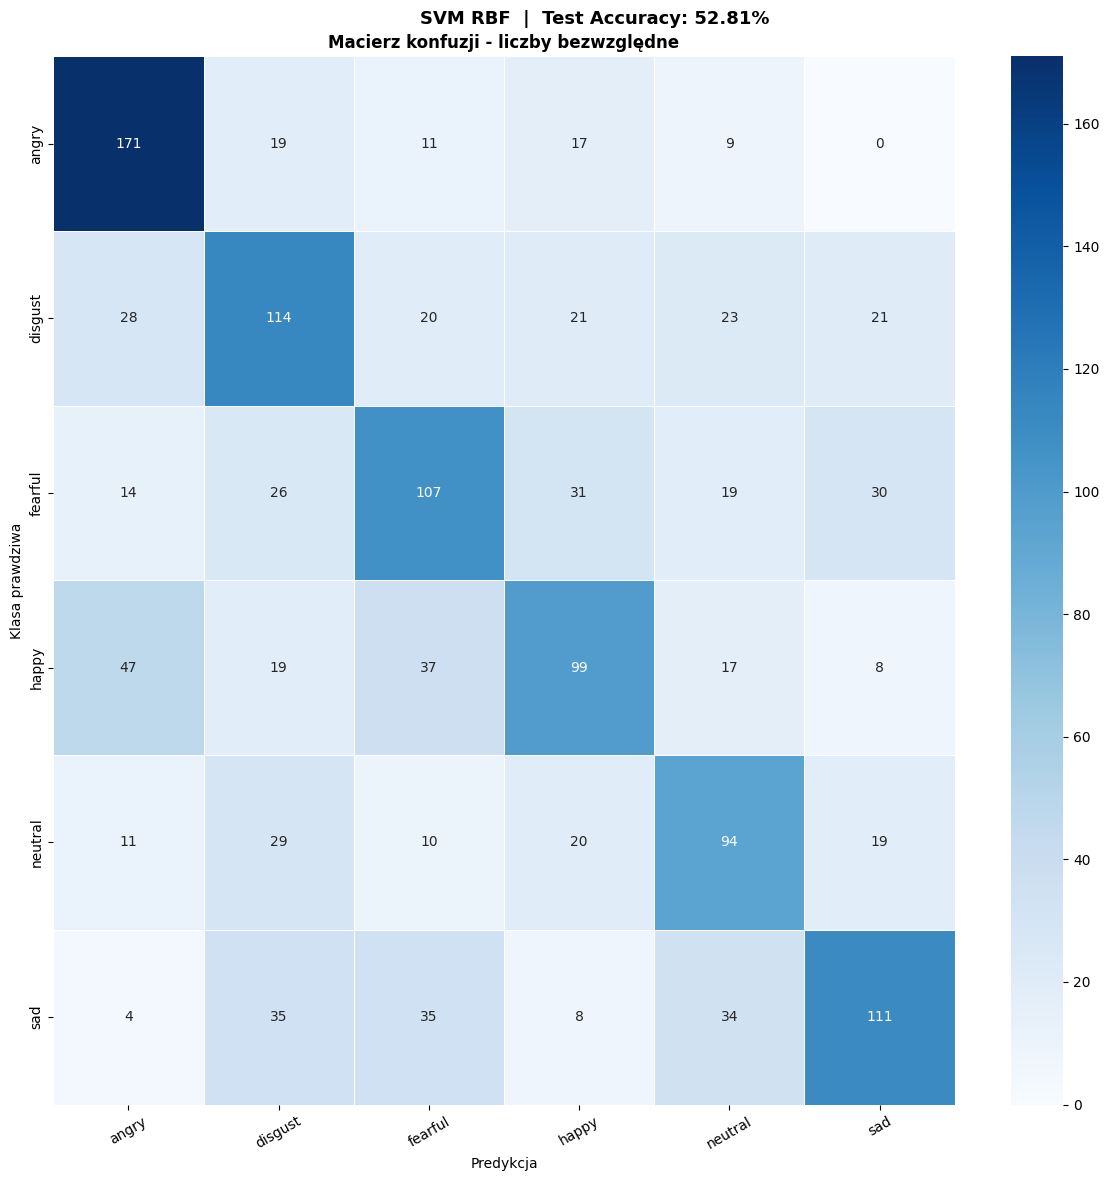

Macierz konfuzji zapisana.


In [107]:
# Macierz konfuzji - test set
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))  # ax zamiast axes
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_title('Macierz konfuzji - liczby bezwzględne', fontsize=12, fontweight='bold')
ax.set_xlabel('Predykcja')
ax.set_ylabel('Klasa prawdziwa')
ax.tick_params(axis='x', rotation=30)

kernel_name = get_svm_kernel(svm_model)
svm_model_name = f'SVM {kernel_name.upper()}'

plt.suptitle(
    f'{svm_model_name}  |  Test Accuracy: {svm_test_acc*100:.2f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'svm_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Macierz konfuzji zapisana.')

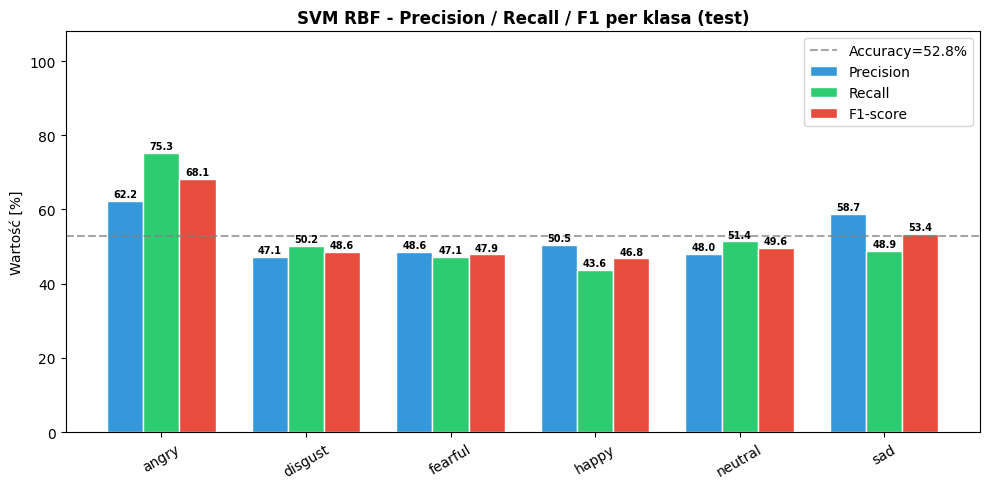

In [108]:
# Wykresy per-class: Precision, Recall, F1
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_test_pred, labels=range(N_CLASSES)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(N_CLASSES)
w = 0.25

bars_p = ax.bar(x - w, precision * 100, w, label='Precision', color='#3498db', edgecolor='white')
bars_r = ax.bar(x, recall * 100, w, label='Recall', color='#2ecc71', edgecolor='white')
bars_f = ax.bar(x + w, f1 * 100, w, label='F1-score', color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_ylim(0, 108)
ax.set_ylabel('Wartość [%]')
ax.set_title(
    f'{svm_model_name} - Precision / Recall / F1 per klasa (test)',
    fontsize=12, fontweight='bold'
)
ax.axhline(svm_test_acc * 100, color='gray', linestyle='--', alpha=0.7,
           label=f'Accuracy={svm_test_acc*100:.1f}%')
ax.legend()

for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'svm_per_class_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.3 Zapis wyników

In [109]:
# Zapis raportu klasyfikacji do CSV
report_df = pd.DataFrame(svm_report_dict).T
report_df.to_csv(RESULTS_DIR / 'svm_classification_report.csv')
print('Raport klasyfikacji zapisany.')

Raport klasyfikacji zapisany.


## 3. CNN

### 3.1 PyTorch GPU

In [110]:
try:
    import torch
    print(f'GPU {"available" if torch.cuda.is_available() else "not available"}')
    print(f'pyTorch {torch.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        'torch', 'torchvision',
        '--index-url', 'https://download.pytorch.org/whl/cpu',
        '-q'
    ])
    import torch
    print(f'PyTorch {torch.__version__} zainstalowany.')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Używane urządzenie: {DEVICE}')

GPU available
pyTorch 2.5.1+cu121
Używane urządzenie: cuda


### 3.2 Przygotowanie spektogramów melowych

In [111]:
# Dodanie wymiaru kanału (mono): (N, 128, 94) w (N, 1, 128, 94)
def to_tensor_dataset(X, y):
    X_t = torch.tensor(X[:, np.newaxis, :, :], dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_t, y_t)

ds_test = to_tensor_dataset(X_mel_test_np, y_mel_test_np)

MEL_H, MEL_W = X_mel_test_np.shape[1], X_mel_test_np.shape[2]

print(f'Test: {X_mel_test_np.shape} w tensor {tuple(ds_test[0][0].shape)}')
print(f'Zakres wartości: [{X_mel_test_np.min():.2f}, {X_mel_test_np.max():.2f}]')

Test: (1318, 128, 94) w tensor (1, 128, 94)
Zakres wartości: [-1.00, 1.00]


### 3.3 Architektura i wczytanie modelu

In [112]:
class EmotionDetectCNN(nn.Module):
    def __init__(self, num_classes, num_filters=(32, 64, 128, 256), dropout=0.5):
        super().__init__()
        f1, f2, f3, f4 = num_filters

        self.conv1 = nn.Conv2d(1,  f1, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(f1)

        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(f2)

        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(f3)

        self.conv4 = nn.Conv2d(f3, f4, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(f4)

        self.pool = nn.MaxPool2d(2)

        # GAP w f4: pole recepcyjne 8x8 przy wejściu 128x94
        self.fc1 = nn.Linear(f4, 256)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.mean(dim=[2, 3])  # Global Average Pooling: (B, f4, H, W) w (B, f4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [113]:
checkpoint = torch.load(
    MODELS_DIR / 'cnn_model.pth',
    map_location=DEVICE,
    weights_only=False
)

config = checkpoint['config']
state_dict = checkpoint['model_state_dict']

cnn_model = EmotionDetectCNN(
    num_classes=N_CLASSES,
    num_filters=config['num_filters'],
    dropout=config['dropout']
)

cnn_model.load_state_dict(state_dict)
cnn_model.to(DEVICE)
cnn_model.eval()

EmotionDetectCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
)

### 3.4 Ewaluacja na zbiorze testowym

In [114]:
loader_test = DataLoader(ds_test, batch_size=64, shuffle=False, num_workers=0)

all_preds, all_labels = [], []
t0 = time.time()
with torch.no_grad():
    for Xb, yb in loader_test:
        Xb = Xb.to(DEVICE)
        test_acc = accuracy_score(y_test, y_test_pred)
        logits = cnn_model(Xb)
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
t1 = time.time()

y_cnn_pred = np.array(all_preds)
y_cnn_true = np.array(all_labels)
cnn_inference_time = t1 - t0

cnn_test_acc = accuracy_score(y_cnn_true, y_cnn_pred)

print('=== Wyniki CNN na zbiorze TEST ===')
print(f'Inference time: {t1 - t0:.2f}s')
print(f'Accuracy: {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)')
print()
print('Classification report:')
print(classification_report(y_cnn_true, y_cnn_pred, target_names=CLASS_NAMES, digits=4))

cnn_report_dict = classification_report(
    y_cnn_true, y_cnn_pred, target_names=CLASS_NAMES, output_dict=True
)

=== Wyniki CNN na zbiorze TEST ===
Inference time: 0.47s
Accuracy: 0.6199 (61.99%)

Classification report:
              precision    recall  f1-score   support

       angry     0.7126    0.7753    0.7426       227
     disgust     0.6085    0.6300    0.6190       227
     fearful     0.5947    0.4978    0.5420       227
       happy     0.6129    0.5022    0.5521       227
     neutral     0.6111    0.7814    0.6859       183
         sad     0.5664    0.5639    0.5651       227

    accuracy                         0.6199      1318
   macro avg     0.6177    0.6251    0.6178      1318
weighted avg     0.6179    0.6199    0.6155      1318



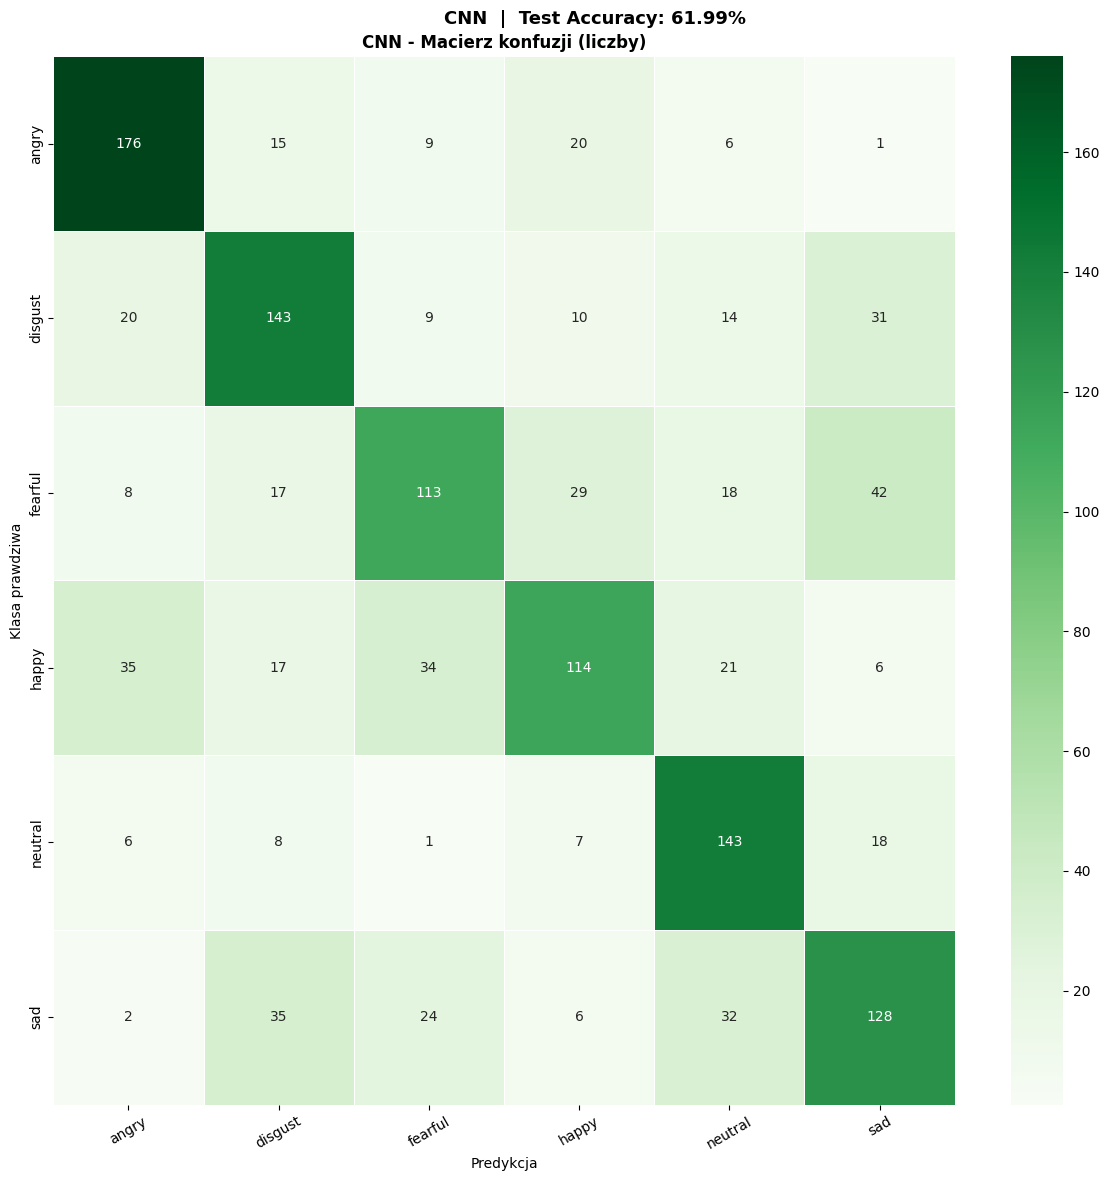

In [115]:
# Macierz konfuzji - CNN, test set
cm_cnn = confusion_matrix(y_cnn_true, y_cnn_pred)
cm_cnn_norm = cm_cnn.astype(float) / cm_cnn.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

sns.heatmap(
    cm_cnn, annot=True, fmt='d', cmap='Greens',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_title('CNN - Macierz konfuzji (liczby)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predykcja')
ax.set_ylabel('Klasa prawdziwa')
ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    f'CNN  |  Test Accuracy: {cnn_test_acc*100:.2f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

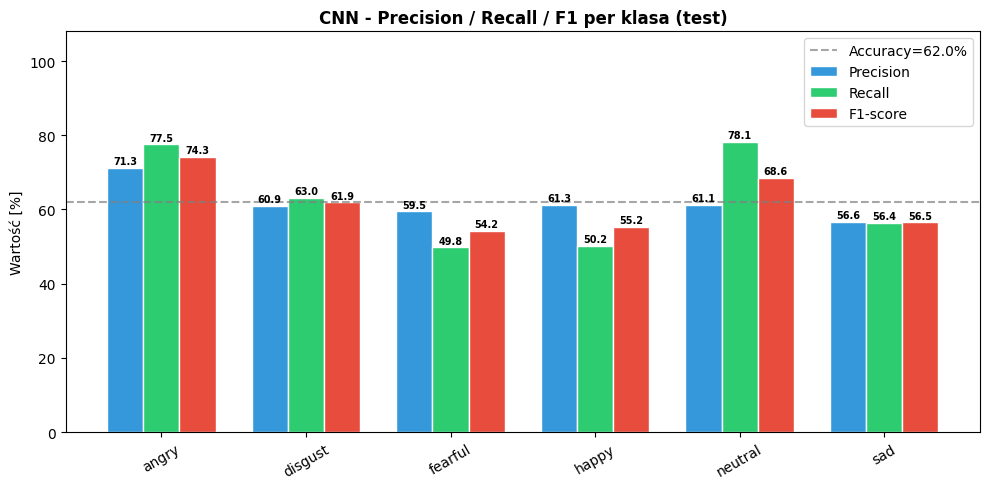

In [116]:
# Wykresy per-class CNN: Precision, Recall, F1
cnn_precision, cnn_recall, cnn_f1, _ = precision_recall_fscore_support(
    y_cnn_true, y_cnn_pred, labels=range(N_CLASSES)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(N_CLASSES)
w = 0.25

bars_p = ax.bar(x - w, cnn_precision * 100, w, label='Precision', color='#3498db', edgecolor='white')
bars_r = ax.bar(x, cnn_recall * 100, w, label='Recall', color='#2ecc71', edgecolor='white')
bars_f = ax.bar(x + w, cnn_f1 * 100, w, label='F1-score', color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_ylim(0, 108)
ax.set_ylabel('Wartość [%]')
ax.set_title('CNN - Precision / Recall / F1 per klasa (test)', fontsize=12, fontweight='bold')
ax.axhline(cnn_test_acc * 100, color='gray', linestyle='--', alpha=0.7,
           label=f'Accuracy={cnn_test_acc*100:.1f}%')
ax.legend()

for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_per_class_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.5 Zapis wyników

In [117]:
# Raport klasyfikacji
cnn_report_df = pd.DataFrame(cnn_report_dict).T
cnn_report_df.to_csv(RESULTS_DIR / 'cnn_classification_report.csv')
print('cnn_classification_report.csv zapisany.')

cnn_classification_report.csv zapisany.


## 4. Model transformer HuBERT

### 4.1 Wczytanie modelu

In [118]:
from transformers import HubertModel


HUBERT_SR = 16_000
LENGTH_S = 3
MAX_SAMPLES = HUBERT_SR * LENGTH_S


class AudioEmotionDataset(Dataset):
    def __init__(self, meta_datasets):
        self.df = pd.concat(meta_datasets, ignore_index=True)

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        wav, _ = torchaudio.load(path)
        # as already normalized -> 3s / mono / 16kHz
        wav = wav.reshape((MAX_SAMPLES,))
        return wav

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav = self._load(row['normalized_path'])
        return wav, int(row['label'])

meta_test = metadata[metadata['split'] == 'test'].reset_index(drop=True)

ds_audio_test = AudioEmotionDataset([meta_test])

print(f'AudioDataset test={len(ds_audio_test)}')
wav_s, lbl_s = ds_audio_test[0]
print(f'Próbka: shape={wav_s.shape}  min={wav_s.min():.3f}  max={wav_s.max():.3f}  label={lbl_s}')

AudioDataset test=1318
Próbka: shape=torch.Size([48000])  min=-1.000  max=1.000  label=0


In [119]:
class HuBERTEmotionClassifier(nn.Module):
    def __init__(self, num_classes, n_frozen_layers=6, dropout=0.3, n_layers_to_pool=4):
        super().__init__()
        self.n_layers_to_pool = n_layers_to_pool

        # use_safetensors=True omija torch.load (wymagany PyTorch>=2.6 dla .bin)
        self.hubert = HubertModel.from_pretrained(
            'facebook/hubert-base-ls960',
            use_safetensors=True,
        )
        hidden_size = self.hubert.config.hidden_size  # 768

        # CNN feature extractor - zawsze zamrożony
        for p in self.hubert.feature_extractor.parameters():
            p.requires_grad = False

        # Pierwsze n_frozen_layers warstw transformera - zamrożone
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i < n_frozen_layers:
                for p in layer.parameters():
                    p.requires_grad = False

        # Uczalne wagi do łączenia ostatnich N warstw (init=0 w softmax w 1/N)
        self.layer_weights = nn.Parameter(torch.zeros(n_layers_to_pool))

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_values):
        out = self.hubert(input_values, output_hidden_states=True)
        hidden = torch.stack(out.hidden_states[-self.n_layers_to_pool:], dim=0)  # (L, B, T, H)
        w = F.softmax(self.layer_weights, dim=0)
        pooled = (hidden * w[:, None, None, None]).sum(0)  # (B, T, H)
        emb = pooled.mean(1)                               # (B, H) - mean over time
        return self.classifier(emb)

    def encoder_trainable_params(self):
        return [p for p in self.hubert.parameters() if p.requires_grad]

    def head_params(self):
        return list(self.classifier.parameters()) + [self.layer_weights]

In [120]:
checkpoint = torch.load(
    MODELS_DIR / 'hubert_model.pth',
    map_location=DEVICE,
    weights_only=False
)

config = checkpoint['config']
state_dict = checkpoint['model_state_dict']

hubert_model = HuBERTEmotionClassifier(
    num_classes=N_CLASSES,
    n_frozen_layers=config['n_frozen_layers'],
    dropout=config['dropout']
)

hubert_model.load_state_dict(state_dict)
hubert_model.to(DEVICE)
hubert_model.eval()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERTEmotionClassifier(
  (hubert): HubertModel(
    (feature_extractor): HubertFeatureEncoder(
      (conv_layers): ModuleList(
        (0): HubertGroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x HubertNoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x HubertNoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): HubertFeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): Hub

### 4.2 Ewaluacja na zbiorze testowym

In [121]:
loader_audio_test = DataLoader(ds_audio_test, batch_size=16, shuffle=False, num_workers=0)
use_amp = (DEVICE.type == 'cuda')

all_preds_h, all_labels_h = [], []
t0 = time.time()
with torch.no_grad():
    for wavs, labels in loader_audio_test:
        wavs = wavs.to(DEVICE)
        if use_amp:
            with torch.autocast('cuda'):
                logits = hubert_model(wavs)
        else:
            logits = hubert_model(wavs)
        all_preds_h.extend(logits.argmax(1).cpu().numpy())
        all_labels_h.extend(labels.numpy())
t1 = time.time()

y_hubert_pred = np.array(all_preds_h)
y_hubert_true = np.array(all_labels_h)
hubert_inference_time = t1 - t0

hubert_test_acc = accuracy_score(y_hubert_true, y_hubert_pred)

print('=== Wyniki HuBERT Base na zbiorze TEST ===')
print(f'Inference time: {t1 - t0:.2f}s')
print(f'Accuracy: {hubert_test_acc:.4f} ({hubert_test_acc*100:.2f}%)')
print()
print('Classification report:')
print(classification_report(y_hubert_true, y_hubert_pred, target_names=CLASS_NAMES, digits=4))

hubert_report_dict = classification_report(
    y_hubert_true, y_hubert_pred, target_names=CLASS_NAMES, output_dict=True
)

=== Wyniki HuBERT Base na zbiorze TEST ===
Inference time: 5.26s
Accuracy: 0.7352 (73.52%)

Classification report:
              precision    recall  f1-score   support

       angry     0.7374    0.9031    0.8119       227
     disgust     0.8305    0.6476    0.7277       227
     fearful     0.7500    0.6740    0.7100       227
       happy     0.8115    0.6828    0.7416       227
     neutral     0.6758    0.9454    0.7882       183
         sad     0.6415    0.5991    0.6196       227

    accuracy                         0.7352      1318
   macro avg     0.7411    0.7420    0.7332      1318
weighted avg     0.7433    0.7352    0.7313      1318



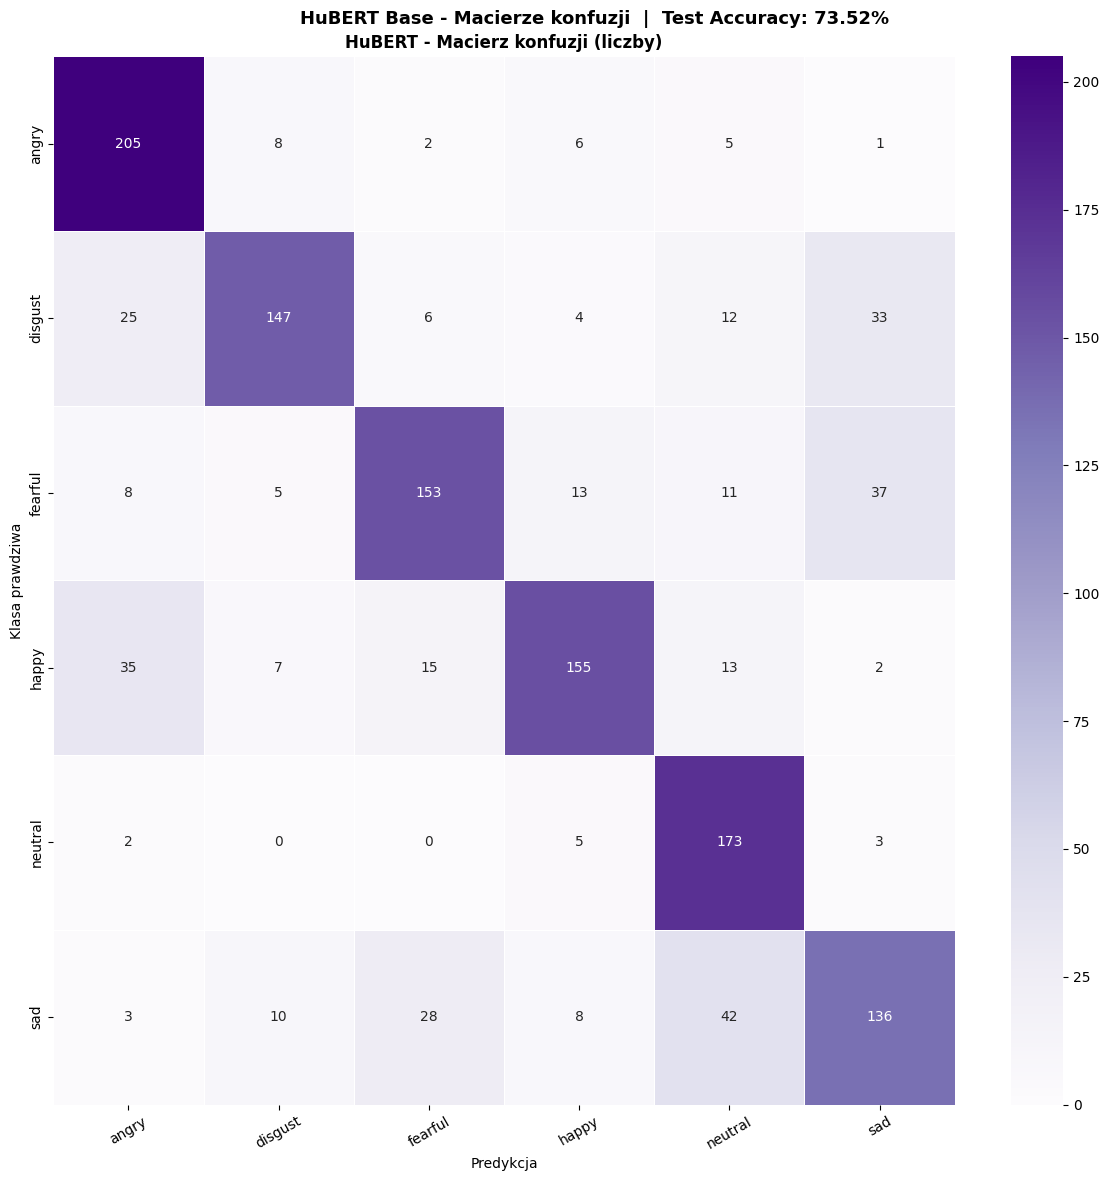

Macierz konfuzji HuBERT zapisana.


In [122]:
cm_h = confusion_matrix(y_hubert_true, y_hubert_pred)
cm_h_norm = cm_h.astype(float) / cm_h.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

sns.heatmap(
    cm_h, annot=True, fmt='d', cmap='Purples',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_title('HuBERT - Macierz konfuzji (liczby)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predykcja')
ax.set_ylabel('Klasa prawdziwa')
ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    f'HuBERT Base - Macierze konfuzji  |  Test Accuracy: {hubert_test_acc*100:.2f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hubert_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Macierz konfuzji HuBERT zapisana.')

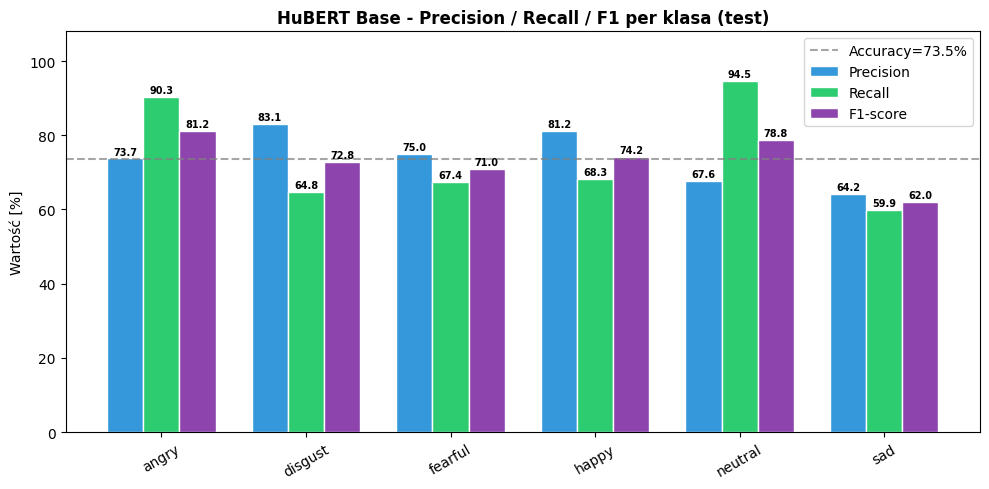

In [123]:
h_precision, h_recall, h_f1, _ = precision_recall_fscore_support(
    y_hubert_true, y_hubert_pred, labels=range(N_CLASSES)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(N_CLASSES)
w = 0.25

bars_p = ax.bar(x - w, h_precision * 100, w, label='Precision', color='#3498db', edgecolor='white')
bars_r = ax.bar(x,     h_recall    * 100, w, label='Recall',    color='#2ecc71', edgecolor='white')
bars_f = ax.bar(x + w, h_f1        * 100, w, label='F1-score',  color='#8e44ad', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_ylim(0, 108)
ax.set_ylabel('Wartość [%]')
ax.set_title('HuBERT Base - Precision / Recall / F1 per klasa (test)',
             fontsize=12, fontweight='bold')
ax.axhline(hubert_test_acc * 100, color='gray', linestyle='--', alpha=0.7,
           label=f'Accuracy={hubert_test_acc*100:.1f}%')
ax.legend()

for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hubert_per_class_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.3 Zapis wyników

In [124]:
pd.DataFrame(hubert_report_dict).T.to_csv(RESULTS_DIR / 'hubert_classification_report.csv')
print('hubert_classification_report.csv zapisany.')

hubert_classification_report.csv zapisany.


## 5. Porównanie modeli

  PORÓWNANIE WSZYSTKICH MODELI
 Model  Inference [ms]  Test Acc [%]  Macro F1 [%]  Macro Recall [%]
   SVM         1165.83         52.81         52.40             52.76
   CNN          468.55         61.99         61.78             62.51
HUBERT         5258.67         73.52         73.32             74.20


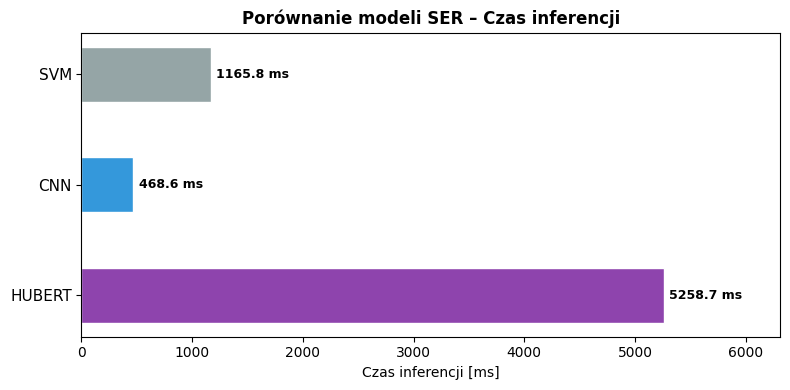

Wykres czasu inferencji zapisany.


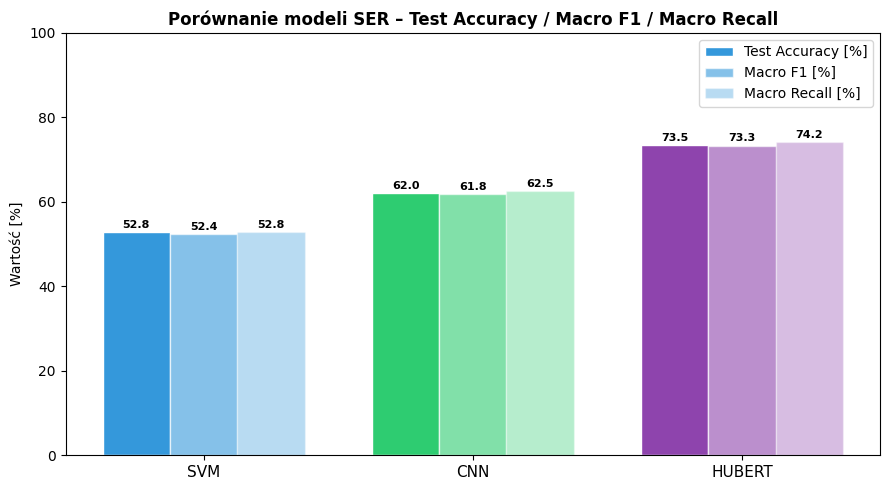

Wykres accuracy/F1/recall zapisany.

Per-class F1 HuBERT (test):
  angry     81.2%  ################
  disgust   72.8%  ##############
  fearful   71.0%  ##############
  happy     74.2%  ##############
  neutral   78.8%  ###############
  sad       62.0%  ############


In [125]:
models_cmp = []

TRAINING_RESULTS_DIR = ROOT_DIR / 'results' / '04_evaluation'

for fname in ['svm', 'cnn', 'hubert']:
    inference_time = globals()[f'{fname}_inference_time']
    acc = globals()[f'{fname}_test_acc']
    report = globals()[f'{fname}_report_dict']
    models_cmp.append({
        'Model': fname.upper(),
        'Inference [ms]': round(inference_time * 1000, 2),
        'Test Acc [%]': round(acc * 100, 2),
        'Macro F1 [%]': round(report['macro avg']['f1-score'] * 100, 2),
        'Macro Recall [%]': round(report['macro avg']['recall'] * 100, 2),
    })

comp_df = pd.DataFrame(models_cmp)
print('=' * 60)
print('  PORÓWNANIE WSZYSTKICH MODELI')
print('=' * 60)
print(comp_df.to_string(index=False))
print('=' * 60)

labels   = [m['Model']             for m in models_cmp]
inf_t    = [m['Inference [ms]']    for m in models_cmp]
tst_a    = [m['Test Acc [%]']      for m in models_cmp]
f1s      = [m['Macro F1 [%]']      for m in models_cmp]
recalls  = [m['Macro Recall [%]']  for m in models_cmp]

# --- Chart 1: Inference time (horizontal) ---
colors_inf = ['#95a5a6', '#3498db', '#8e44ad']
fig1, ax1 = plt.subplots(figsize=(8, 4))
y = np.arange(len(models_cmp))
bars = ax1.barh(y, inf_t, color=colors_inf[:len(labels)], edgecolor='white', height=0.5)
ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=11)
ax1.set_xlabel('Czas inferencji [ms]')
ax1.set_title('Porównanie modeli SER – Czas inferencji',
              fontsize=12, fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars, inf_t):
    ax1.text(bar.get_width() + max(inf_t) * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f} ms', va='center', fontsize=9, fontweight='bold')
ax1.set_xlim(0, max(inf_t) * 1.2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'models_inference_time.png', bbox_inches='tight', dpi=150)
plt.show()
print('Wykres czasu inferencji zapisany.')

# --- Chart 2: Test Accuracy / Macro F1 / Macro Recall (grouped vertical) ---
x = np.arange(len(models_cmp))
w = 0.25
model_colors = ['#3498db', '#2ecc71', '#8e44ad']

fig2, ax2 = plt.subplots(figsize=(9, 5))
b_acc = ax2.bar(x - w, tst_a,   w, label='Test Accuracy [%]',
                color=model_colors[:len(labels)], edgecolor='white')
b_f1  = ax2.bar(x,     f1s,     w, label='Macro F1 [%]',
                color=model_colors[:len(labels)], edgecolor='white', alpha=0.6)
b_rec = ax2.bar(x + w, recalls, w, label='Macro Recall [%]',
                color=model_colors[:len(labels)], edgecolor='white', alpha=0.35)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim(0, 100)
ax2.set_ylabel('Wartość [%]')
ax2.set_title('Porównanie modeli SER – Test Accuracy / Macro F1 / Macro Recall',
              fontsize=12, fontweight='bold')
ax2.legend()

for bar in list(b_acc) + list(b_f1) + list(b_rec):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
             f'{h:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'models_accuracy_f1.png', bbox_inches='tight', dpi=150)
plt.show()
print('Wykres accuracy/F1/recall zapisany.')

print('\nPer-class F1 HuBERT (test):')
for em, score in zip(CLASS_NAMES, h_f1):
    bar_str = '#' * int(score * 20)
    print(f'  {em:8s} {score*100:5.1f}%  {bar_str}')
